In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px 
import seaborn as sns

In [7]:
# Get csv file 
relact = pd.read_csv("FlA_ZP_RelAct_full.csv", sep=";")


# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# Drop the intermediate reference column 
relact.drop(columns=["%SAM_converted_ref"], inplace=True)

relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())

relact_var.sort_values(by="Relative_Activity").tail(50)

,Sample_ID,Plate,Protein,Time(min),SAM_conc(uM),Replicate,Inj_Vol(ul),Dilution,FDA_Area,SAM_Area,FDA_Corr,SAM_corr,%SAM_converted,Relative_Activity
269,H191E_5min_300uM_1,ZP2-1,H191E,5,300,1,20,2,0.8345,25.5456,0.8345,25.5456,3.163369,1.097695
988,H191K_2min_300uM_3,ZP_Rep4-2,H191K,2,300,3,20,2,0.4439,29.4605,0.4439,29.4605,1.484397,1.097789
845,H191E_2min_300uM_3,ZP_Rep2-1,H191E,2,300,3,20,2,0.2807,19.2673,0.2807,19.2673,1.435953,1.099012
467,A298P_2min_300uM_2,ZP2-3,A298P,2,300,2,20,2,0.4372,28.2512,0.4372,28.2512,1.523961,1.100022
293,H191E_5min_10uM_2,ZP2-1,H191E,5,10,2,20,2,0.3105,0.7810,0.3105,0.7810,28.447091,1.100150
466,A2Q_2min_300uM_2,ZP2-3,A2Q,2,300,2,20,2,0.4401,28.4266,0.4401,28.4266,1.524594,1.100479
425,A298P_2min_300uM_1,ZP2-3,A298P,2,300,1,20,2,0.4655,28.7355,0.4655,28.7355,1.594123,1.100531
86,S166A_5min_300uM_1,ZP1-2,S166A,5,300,1,10,2,0.5237,18.8026,1.0474,37.6052,2.709779,1.101196
894,E297T_2min_300uM_3,ZP_Rep2-2,E297T,2,300,3,20,2,0.3846,26.6548,0.3846,26.6548,1.422369,1.104718
822,I239T_5min_10uM_3,ZP_Rep3-2,I239T,5,10,3,20,2,0.3508,0.7588,0.3508,0.7588,31.614996,1.105649


In [8]:
# Get csv file with model rankings
ZP_pred = pd.read_csv("FlA_HIM_SMscan_full_sorted_ESM1b&TranceptEVE&ESM-IF1.csv", sep=";") 

# Add bin and rank columns for each model
relact_var_models = relact_var.merge(
    ZP_pred[["mutant", "ESM1b_bin", "ESM1b_rank", "ESM1b_score", "TranceptEVE_bin", "TranceptEVE_rank", "TranceptEVE_score", "ESM-IF1_bin", "ESM-IF1_rank", "ESM-IF1_score"]],
    left_on="Protein", right_on="mutant",
    how="left"
)

relact_var_models = relact_var_models.dropna(subset="mutant") ### drop all variants that werent in the dataset predicted by the ZSM

relact_var_models.drop(columns=["mutant"], inplace=True)

# Add selection metrics for testing 
singles = ["ESM1b", "TranceptEVE", "ESM-IF1"]
doubles = ["ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

for model in singles:
    relact_var_models[model] = [True if rank <= 10 else False for rank in relact_var_models[f"{model}_rank"]] ### if rank is equal to or higher than 10, counts to that model
    
for model in doubles:
    bins = model.split("_")
    relact_var_models[model] = False ### initialize column
    relact_var_models.loc[(relact_var_models[f"{bins[0]}_bin"] == 1) & (relact_var_models[f"{bins[1]}_bin"] == 1), model] = True ### if both models predict as faster variant, counts to that model


# Get TranceptEVE_ESM-IF1 combined rank score
relact_var_models["ESM1b_TranceptEVE_rank"] = relact_var_models["ESM1b_rank"] + relact_var_models["TranceptEVE_rank"]
relact_var_models["ESM1b_ESM-IF1_rank"] = relact_var_models["ESM1b_rank"] + relact_var_models["ESM-IF1_rank"]
relact_var_models["TranceptEVE_ESM-IF1_rank"] = relact_var_models["TranceptEVE_rank"] + relact_var_models["ESM-IF1_rank"]

relact_var_models["TranceptEVE_ESM-IF1"] = [True if rank <= 116 else False for rank in relact_var_models["TranceptEVE_ESM-IF1_rank"]] ### Special treatment for this combination: only top ten when combining rankings are included in model

relact_var_models.tail(10)        

,Sample_ID,Plate,Protein,Time(min),SAM_conc(uM),Replicate,Inj_Vol(ul),Dilution,FDA_Area,SAM_Area,...,ESM-IF1_score,ESM1b,TranceptEVE,ESM-IF1,ESM1b_TranceptEVE,ESM1b_ESM-IF1,TranceptEVE_ESM-IF1,ESM1b_TranceptEVE_rank,ESM1b_ESM-IF1_rank,TranceptEVE_ESM-IF1_rank
876,Y77S_3h_300uM_3,ZP_Rep4-2,Y77S,180,300,3,20,2,0.5736,27.6793,...,-1.117465,True,False,False,False,False,False,2358.5,2516.0,4862.5
877,F190V_3h_300uM_3,ZP_Rep4-2,F190V,180,300,3,20,2,8.8261,21.7468,...,-1.084098,False,False,True,False,False,False,2864.0,1571.0,1311.0
878,W50Q_3h_300uM_3,ZP_Rep4-2,W50Q,180,300,3,20,2,0.0697,28.9997,...,-1.087583,False,False,False,False,False,True,3421.0,3364.0,109.0
879,H191K_3h_300uM_3,ZP_Rep4-2,H191K,180,300,3,20,2,10.1659,22.3623,...,-1.091191,False,False,False,False,False,True,629.0,676.0,115.0
880,K234T_3h_300uM_3,ZP_Rep4-2,K234T,180,300,3,20,2,9.7825,22.6246,...,-1.091042,False,False,False,False,False,True,602.0,638.0,116.0
882,Y77S_3h_10uM_3,ZP_Rep4-2,Y77S,180,10,3,20,2,0.0143,0.8374,...,-1.117465,True,False,False,False,False,False,2358.5,2516.0,4862.5
883,F190V_3h_10uM_3,ZP_Rep4-2,F190V,180,10,3,20,2,0.8718,0.3681,...,-1.084098,False,False,True,False,False,False,2864.0,1571.0,1311.0
884,W50Q_3h_10uM_3,ZP_Rep4-2,W50Q,180,10,3,20,2,0.0283,0.9109,...,-1.087583,False,False,False,False,False,True,3421.0,3364.0,109.0
885,H191K_3h_10uM_3,ZP_Rep4-2,H191K,180,10,3,20,2,0.8728,0.3392,...,-1.091191,False,False,False,False,False,True,629.0,676.0,115.0
886,K234T_3h_10uM_3,ZP_Rep4-2,K234T,180,10,3,20,2,0.8151,0.3351,...,-1.091042,False,False,False,False,False,True,602.0,638.0,116.0


In [9]:
### Save intermediate dataset
relact_var_models.to_csv("FlA_ZP_Relact_var.csv")

In [10]:
### Add Abou's dataset to the DataFrame
abou_data = pd.read_csv("FlA_HIM_relativeActivity.csv", sep=";")
temp = pd.DataFrame({
    "Sample_ID": abou_data["Name"].tolist(), 
    "Relative_Activity": abou_data["Relative activity (%)"].tolist()
})

### Convert from percentage
temp["Relative_Activity"] = temp["Relative_Activity"]/100

relact_comb = pd.concat([relact_var_models, temp], ignore_index=True)

### Add reaction data
relact_comb["Time(min)"] = relact_comb["Time(min)"].fillna(180)
relact_comb["SAM_conc(uM)"] = relact_comb["SAM_conc(uM)"].fillna(300)

### Assign false for all models 
models = ["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]
for model in models:
    relact_comb[model] = relact_comb[model].fillna(False)

### Create new category for selection dataset
relact_comb["Selection_Dataset"] = False
relact_comb["Selection_Dataset"] = relact_comb["Sample_ID"].str.contains("HiM", case=False)


relact_comb.tail(60)

C:\Users\ckuwe\AppData\Local\Temp\ipykernel_10156\3546596627.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  relact_comb[model] = relact_comb[model].fillna(False)


,Sample_ID,Plate,Protein,Time(min),SAM_conc(uM),Replicate,Inj_Vol(ul),Dilution,FDA_Area,SAM_Area,...,ESM1b,TranceptEVE,ESM-IF1,ESM1b_TranceptEVE,ESM1b_ESM-IF1,TranceptEVE_ESM-IF1,ESM1b_TranceptEVE_rank,ESM1b_ESM-IF1_rank,TranceptEVE_ESM-IF1_rank,Selection_Dataset
718,Y77S_5min_300uM_3,ZP_Rep4-2,Y77S,5.0,300.0,3.0,20.0,2.0,0.0182,31.1201,...,True,False,False,False,False,False,2358.5,2516.0,4862.5,False
719,F190V_5min_300uM_3,ZP_Rep4-2,F190V,5.0,300.0,3.0,20.0,2.0,0.8809,29.2630,...,False,False,True,False,False,False,2864.0,1571.0,1311.0,False
720,W50Q_5min_300uM_3,ZP_Rep4-2,W50Q,5.0,300.0,3.0,20.0,2.0,0.0000,30.4544,...,False,False,False,False,False,True,3421.0,3364.0,109.0,False
721,H191K_5min_300uM_3,ZP_Rep4-2,H191K,5.0,300.0,3.0,20.0,2.0,1.0408,29.5780,...,False,False,False,False,False,True,629.0,676.0,115.0,False
722,K234T_5min_300uM_3,ZP_Rep4-2,K234T,5.0,300.0,3.0,20.0,2.0,0.9498,29.1413,...,False,False,False,False,False,True,602.0,638.0,116.0,False
723,Y77S_5min_10uM_3,ZP_Rep4-2,Y77S,5.0,10.0,3.0,20.0,2.0,0.0000,1.0208,...,True,False,False,False,False,False,2358.5,2516.0,4862.5,False
724,F190V_5min_10uM_3,ZP_Rep4-2,F190V,5.0,10.0,3.0,20.0,2.0,0.3067,0.7987,...,False,False,True,False,False,False,2864.0,1571.0,1311.0,False
725,W50Q_5min_10uM_3,ZP_Rep4-2,W50Q,5.0,10.0,3.0,20.0,2.0,0.0000,0.9974,...,False,False,False,False,False,True,3421.0,3364.0,109.0,False
726,H191K_5min_10uM_3,ZP_Rep4-2,H191K,5.0,10.0,3.0,20.0,2.0,0.3153,0.7546,...,False,False,False,False,False,True,629.0,676.0,115.0,False
727,K234T_5min_10uM_3,ZP_Rep4-2,K234T,5.0,10.0,3.0,20.0,2.0,0.3258,0.7548,...,False,False,False,False,False,True,602.0,638.0,116.0,False


In [11]:
print(pd.unique(relact_var_models.loc[relact_var_models["TranceptEVE_ESM-IF1"], "Protein"]))

['S166A' 'H191E' 'G37D' 'H191D' 'H32L' 'H235R' 'W50Q' 'I239T' 'H191K'
 'K234T']


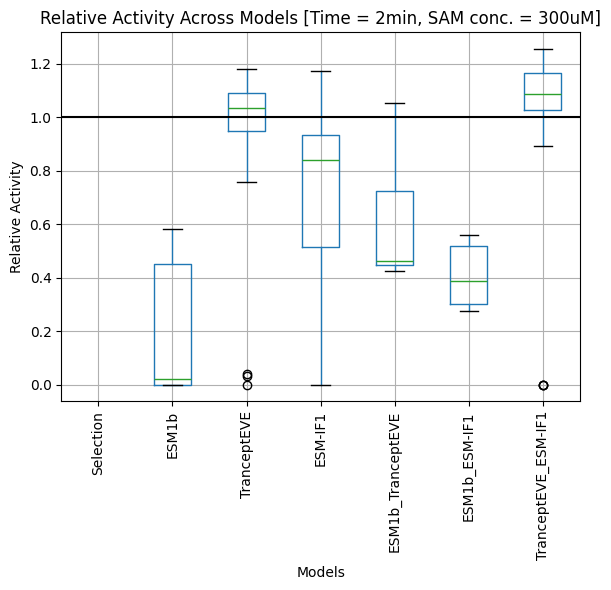

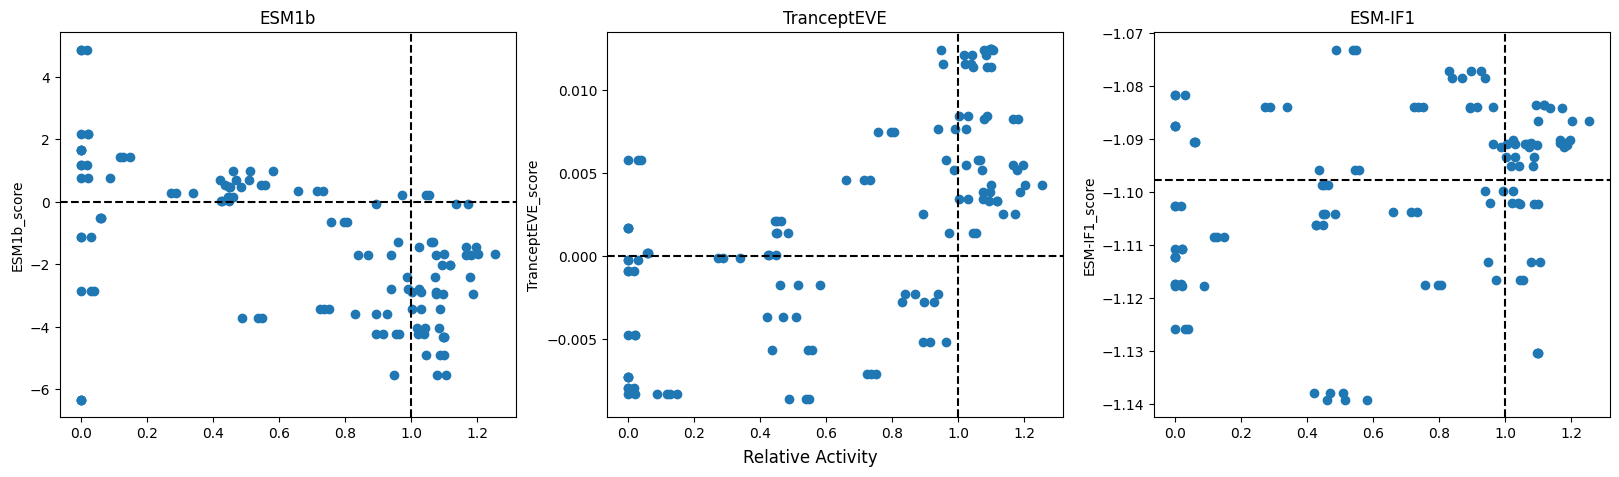

In [12]:
#Set timepoint and SAM conc.
t=2 ### [2,5,180]
SAM=300 ### [10,300]

#Plotting - boxplot over different models
subset = relact_comb.loc[(relact_comb["Time(min)"] == t) & (relact_comb["SAM_conc(uM)"] == SAM)]
boxplot_relact = pd.DataFrame(
    {
        "Selection": subset.loc[subset["Selection_Dataset"], "Relative_Activity"],
        "ESM1b": subset.loc[subset["ESM1b"], "Relative_Activity"],
        "TranceptEVE": subset.loc[subset["TranceptEVE"], "Relative_Activity"],
        "ESM-IF1": subset.loc[subset["ESM-IF1"], "Relative_Activity"],
        "ESM1b_TranceptEVE": subset.loc[subset["ESM1b_TranceptEVE"], "Relative_Activity"],
        "ESM1b_ESM-IF1": subset.loc[subset["ESM1b_ESM-IF1"], "Relative_Activity"],
        "TranceptEVE_ESM-IF1": subset.loc[subset["TranceptEVE_ESM-IF1"], "Relative_Activity"]
    }
)


plt.figure(figsize=(6, 6))
boxplot_relact.boxplot()
plt.title(f"Relative Activity Across Models [Time = {t}min, SAM conc. = {SAM}uM]")
plt.axhline(y=1, color="black", linestyle = "-")
plt.ylabel("Relative Activity")
plt.xlabel("Models")
plt.xticks(rotation=90)  # Rotate x-axis labels to vertical
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()


### Create Scatter plots of relative activity vs. model score for each model over all mutations (not just the ones identified by each model)
fig, axs= plt.subplots(1,3, figsize=(20,5))
fig.supxlabel("Relative Activity")
models=["ESM1b", "TranceptEVE", "ESM-IF1"]
WT_score=[0,0,-1.097821] ### The score of the WT protein for each model
for i in range(len(models)):
    axs[i].scatter(x=subset["Relative_Activity"], y=subset[f"{models[i]}_score"])
    axs[i].axhline(y=WT_score[i], color="black", linestyle = "--")
    axs[i].axvline(x=1, color="black", linestyle = "--")
    axs[i].set_title(models[i])
    axs[i].set_ylabel(f"{models[i]}_score")

plt.show()

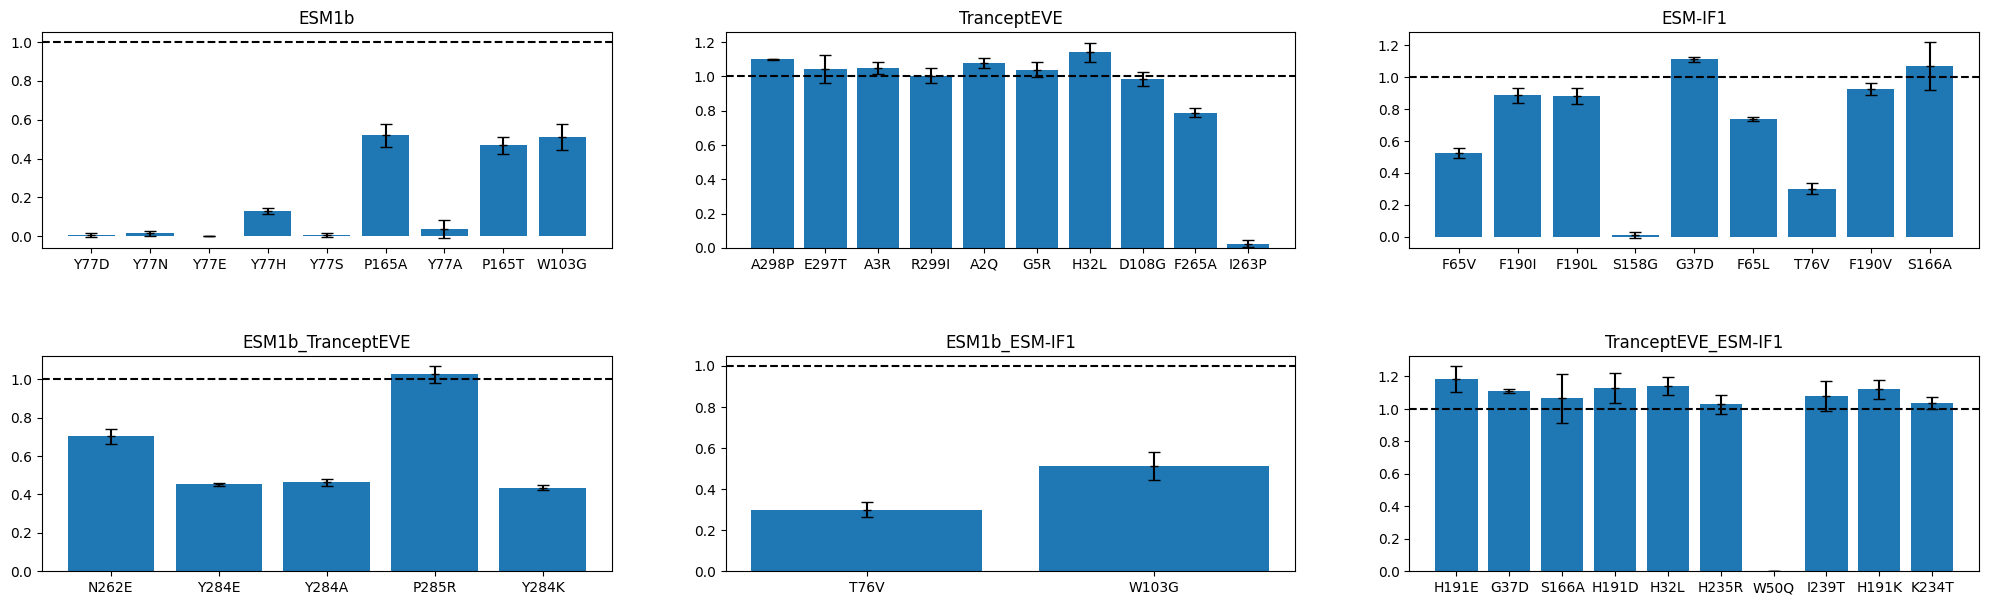

In [13]:
### Plotting - plot by model and protein

time = 2 ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]

models=["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

fig, axs= plt.subplots(2,3, figsize=(25,7))
# fig.supylabel("Relative Activity") ###idk why its creating such a huge space :(

row=0
col=0

for model in models:

    subset = relact_var_models.loc[relact_var_models[model] & (relact_var_models["Time(min)"] == time) & (relact_var_models["SAM_conc(uM)"] == SAM)]
    #print(pd.unique(subset["Protein"]))

    ### Restructure dataset and calculate mean & stddev per protein
    subset = pd.melt(subset, id_vars=["Protein", f"{model}_rank"], value_vars=["Relative_Activity"])
    plotdata = subset.groupby("Protein")["value"].agg(["mean", "std"]).reset_index()
    plotdata = plotdata.merge(subset[["Protein", f"{model}_rank"]], on="Protein", how="left").sort_values(f"{model}_rank").drop_duplicates().reset_index(drop=True)
    # print(plotdata)

    axs[col,row].bar(x=plotdata["Protein"], height=plotdata["mean"])
    axs[col,row].errorbar(x=plotdata["Protein"], y=plotdata["mean"], yerr=plotdata["std"], fmt="_", color="black", capsize=4)
    axs[col,row].axhline(y=1, color="black", linestyle = "--")
    axs[col,row].set_title(model)
    #axs[col,row].set_ylabel("Relative Activity")
    
    row+=1
    if row >2:
        row=0
        col+=1
        
plt.subplots_adjust(hspace=0.5)
plt.show()
    

### Double Mutants
Cleaning the df and plotting


In [ ]:
### Double Mutants

# Get csv file 
relact = pd.read_csv("FlA_ZP_double.csv", sep=";")


# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# Drop the intermediate reference column 
relact.drop(columns=["%SAM_converted_ref"], inplace=True)


relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())
# print(relact_var)
relact_var = relact_var.drop(relact_var.index[relact_var["Plate"] == "ZP-double_2"].tolist())
# print(relact_var)


time = [2, 5, 180] ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]

# relact_var["Time(min)"] == time) & 

subset = relact_var.loc[(relact_var["SAM_conc(uM)"] == SAM)]
# print(subset)
### Restructure dataset and calculate mean & stddev per protein
subset = pd.melt(subset, id_vars=["Protein", "Time(min)"], value_vars=["Relative_Activity"])
# print(subset)
plotdata = subset.groupby(by=["Protein", "Time(min)"])["value"].agg(["mean", "std"]).reset_index()
# print(plotdata)
# plotdata = plotdata.merge(subset[["Protein", "Time(min)"]], on="Protein", how="left").drop_duplicates().reset_index(drop=True)
plotdata.drop(plotdata.loc[plotdata["Protein"] == "Ctrl"].index, inplace=True)
plotdata.drop(plotdata.loc[plotdata["Protein"] == "N4V"].index, inplace=True)
# print(plotdata)
# print(plotdata)


# for i in range(len(time)):
#     nodata= pd.DataFrame({"Protein": "H191E-H32L", "Time(min)": [time[i]], "mean": [0], "std": [0]})
#     plotdata = pd.concat([plotdata, nodata])

plotdata['Time(min)'] = plotdata['Time(min)'].astype(str)




print(plotdata)

fig = px.bar(plotdata, x="Protein", y="mean", color="Time(min)", barmode="group", error_y="std", color_discrete_sequence=["#516F84","#DF9966","#FFEFD3"], width=800, height=400,
             labels={
                 "Protein": "Mutants", 
                 "mean": "Relative Activity"
             },
             category_orders={"Protein": ["S166A-H32L", "S166A-G37D", "S166A-H191E", "H32L-H191E", "G37D-H32L", "H191E-G37D", "H32L-G37D-S166A", "H32L-S166A-H191E", "G37D-S166A-H191E", "H32L-G37D-S166A-H191E"]})
fig.update_traces(marker_line_color="black", marker_line_width = 1.0)
fig.add_hline(y=1, line_dash="dash")
fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)

fig.show()


                  Protein Time(min)      mean       std
18             H32L-H191E         2  1.107974  0.002866
33             S166A-H32L         2  1.018917  0.071824
12        H32L-G37D-S166A         2  1.065837  0.006161
9              H191E-G37D         2  0.978446  0.099768
27             S166A-G37D         2  1.001996  0.086920
6        G37D-S166A-H191E         2  1.071873  0.047276
30            S166A-H191E         2  1.016524  0.037825
15  H32L-G37D-S166A-H191E         2  1.123937  0.016377
21       H32L-S166A-H191E         2  1.085669  0.017334
3               G37D-H32L         2  1.002607  0.065219
13        H32L-G37D-S166A         5  1.044082  0.059254
10             H191E-G37D         5  1.003844  0.048909
4               G37D-H32L         5  1.024527  0.050675
22       H32L-S166A-H191E         5  1.035308  0.053764
7        G37D-S166A-H191E         5  1.027598  0.021914
31            S166A-H191E         5  1.022483  0.045153
28             S166A-G37D         5  0.986694  0

In [15]:
subset = relact_var
# print(subset)
### Restructure dataset and calculate mean & stddev per protein
subset = pd.melt(subset, id_vars=["Protein", "Time(min)", "SAM_conc(uM)"], value_vars=["Relative_Activity"])
# print(subset)
plotdata = subset.groupby(by=["Protein", "Time(min)", "SAM_conc(uM)"])["value"].agg(["mean", "std"]).reset_index()
# plotdata = plotdata.merge(subset[["Protein", "Time(min)"]], on="Protein", how="left").drop_duplicates().reset_index(drop=True)
plotdata.drop(plotdata.loc[plotdata["Protein"] != "N4V"].index, inplace=True)
# plotdata["Sample"] = plotdata["Protein"] + "_" + plotdata["SAM_conc(uM)"].astype(str) + "uM"
print(plotdata)
# plotdata.drop(plotdata.loc[plotdata["Protein"] == "N4V"].index, inplace=True)


plotdata['Time(min)'] = plotdata['Time(min)'].astype(str)

fig = px.bar(plotdata, x="SAM_conc(uM)", y="mean", color="Time(min)", barmode="group", error_y="std", color_discrete_sequence=["#516F84","#DF9966","#FFEFD3"], width=600, height=400,
             labels={
                 "SAM_conc(uM)": "SAM Conc. [uM]", 
                 "mean": "Relative Activity"
             })
fig.update_traces(marker_line_color="black", marker_line_width = 1.0)
fig.add_hline(y=1, line_dash="dash")
fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)

fig.show()

   Protein  Time(min)  SAM_conc(uM)      mean       std
18     N4V          2            10  1.863565  0.095957
19     N4V          2           300  1.976754  0.228586
20     N4V          5            10  1.673633  0.063597
21     N4V          5           300  1.982460  0.018805
22     N4V        180            10  1.035034  0.007764
23     N4V        180           300  1.351096  0.000405


### Rational Engineered SPM

In [18]:
# Get csv file 
relact = pd.read_csv("FlA_ZP_RatEng.csv", sep=";")


# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# Drop the intermediate reference column 
relact.drop(columns=["%SAM_converted_ref"], inplace=True)

relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())
# print(relact_var)


time = [2, 180] ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]

# relact_var["Time(min)"] == time) & 

subset = relact_var.loc[(relact_var["SAM_conc(uM)"] == SAM)]
# print(subset)
### Restructure dataset and calculate mean & stddev per protein
subset = pd.melt(subset, id_vars=["Protein", "Time(min)"], value_vars=["Relative_Activity"])
# print(subset)
plotdata = subset.groupby(by=["Protein", "Time(min)"])["value"].agg(["mean", "std"]).reset_index()
# print(plotdata)
# plotdata = plotdata.merge(subset[["Protein", "Time(min)"]], on="Protein", how="left").drop_duplicates().reset_index(drop=True)
plotdata.drop(plotdata.loc[plotdata["Protein"] == "Ctrl"].index, inplace=True)
# plotdata.drop(plotdata.loc[plotdata["Protein"] == "N4V"].index, inplace=True)
# print(plotdata)
# print(plotdata)


# for i in range(len(time)):
#     nodata= pd.DataFrame({"Protein": "H191E-H32L", "Time(min)": [time[i]], "mean": [0], "std": [0]})
#     plotdata = pd.concat([plotdata, nodata])
plotdata = plotdata.sort_values("Protein")

plotdata['Time(min)'] = plotdata['Time(min)'].astype(str)


fig = px.bar(plotdata, x="Protein", y="mean", color="Time(min)", barmode="group", error_y="std", color_discrete_sequence=["#516F84","#DF9966","#FFEFD3"], width=800, height=400,
             labels={
                 "Protein": "Mutants", 
                 "mean": "Relative Activity"
             }, 
             category_orders={"Protein": ["N4V", "I120V", "Q26I", "S106A", "F110E", "F110I", "Q232Y", "K237R"]})
fig.update_traces(marker_line_color="black", marker_line_width = 1.0)
fig.add_hline(y=1, line_dash="dash")
fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)

fig.show()

### N-terminal full screen


In [19]:
# Get csv file 
relact = pd.read_csv("FlA_ZP_Nterm.csv", sep=";")


# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# Drop the intermediate reference column 
relact.drop(columns=["%SAM_converted_ref"], inplace=True)

relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())
# print(relact_var)


time = [2, 180] ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]

# relact_var["Time(min)"] == time) & 

subset = relact_var.loc[(relact_var["SAM_conc(uM)"] == SAM)]
# print(subset)
### Restructure dataset and calculate mean & stddev per protein
subset = pd.melt(subset, id_vars=["Protein", "Time(min)"], value_vars=["Relative_Activity"])
# print(subset)
plotdata = subset.groupby(by=["Protein", "Time(min)"])["value"].agg(["mean", "std"]).reset_index()
# print(plotdata)
# plotdata = plotdata.merge(subset[["Protein", "Time(min)"]], on="Protein", how="left").drop_duplicates().reset_index(drop=True)
plotdata.drop(plotdata.loc[plotdata["Protein"] == "Ctrl"].index, inplace=True)
# plotdata.drop(plotdata.loc[plotdata["Protein"] == "N4V"].index, inplace=True)
# print(plotdata)
# print(plotdata)


# for i in range(len(time)):
#     nodata= pd.DataFrame({"Protein": "H191E-H32L", "Time(min)": [time[i]], "mean": [0], "std": [0]})
#     plotdata = pd.concat([plotdata, nodata])
plotdata = plotdata.sort_values("Protein")

plotdata['Time(min)'] = plotdata['Time(min)'].astype(str)


fig = px.bar(plotdata, x="Protein", y="mean", color="Time(min)", barmode="group", error_y="std", color_discrete_sequence=["#516F84","#DF9966","#FFEFD3"], width=800, height=400,
             labels={
                 "Protein": "Mutants", 
                 "mean": "Relative Activity"
             }, 
             category_orders={"Protein": ["N4V", "I120V", "S166A", "N4V-S166A", "I120V-S166A", "N4V-I120V-S166A"]})
fig.update_traces(marker_line_color="black", marker_line_width = 1.0)
fig.add_hline(y=1, line_dash="dash")
fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='white'
)

fig.show()

In [16]:
### Temp scan
# Get csv file 
tempcurve = pd.read_csv("FlA_TempCurve.csv", sep=";")
# print(tempcurve)


tempcurve = pd.melt(tempcurve, id_vars=["Protein", "Timepoint", "Temp."], value_vars=["%SAM converted"])
# print(subset)
tempcurve = tempcurve.groupby(by=["Protein", "Timepoint", "Temp."])["value"].agg(["mean", "std"]).reset_index()
tempcurve["Timepoint"] = tempcurve["Timepoint"].astype(str)
print(tempcurve)

fig = px.scatter(tempcurve, x="Temp.", y="mean", color="Timepoint", error_y="std", color_discrete_sequence=["#516F84","#DF9966","#FFEFD3"], width=600, height=400,
             labels={
                 "Temp.": "Temperature [C]", 
                 "mean": "SAM conversion [%]",
                 "Timepoint": "Time [min]"
             })
fig.update_traces(marker_line_color="black", marker_line_width = 1.0)
fig.add_hline(y=0)
fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='gray'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='gray'
)

fig.show()

   Protein Timepoint  Temp.       mean       std
0       WT         2     32   0.870568  0.038878
1       WT         2     37   1.226882  0.063573
2       WT         2     42   1.680621  0.085255
3       WT         2     47   2.089802  0.078579
4       WT         2     50   2.931572  0.032235
5       WT         2     52   2.881089  0.230687
6       WT         2     54   3.048644  0.000512
7       WT         2     56   3.048511  0.090297
8       WT         2     57   2.998269  0.088458
9       WT         2     58   2.576019  0.032640
10      WT         2     60   1.461262  0.012489
11      WT         2     62   0.482341  0.098944
12      WT         2     67   0.064873  0.042188
13      WT         2     72   0.022216  0.011487
14      WT         2     77   0.010276  0.008640
15      WT        60     37  18.016697  0.193880
16      WT        60     42  21.676194  0.008734
17      WT        60     44  22.691866  0.070460
18      WT        60     46  23.628051  0.033432
19      WT        60

In [91]:
tranceptEVE = ZP_pred.loc[ZP_pred["TranceptEVE_bin"]==1].sort_values(by="Pos")
# print(tranceptEVE)
pos = tranceptEVE["Pos"].unique()

for i in range(len(pos)):
    pos[i] = pos[i].translate({ord(i): None for i in "[]"})
    
pos = pos.astype(int)
pos.sort()
# print(pos)
# print(len(pos))

pymol_pos = ""
pos_str = pos.astype(str)
for string in pos_str:
    pymol_pos += string
    pymol_pos += '+'
    
print(f"tranceptEVE: {pymol_pos}")


tranceptEVExESMIF1 = tranceptEVE.loc[ZP_pred["ESM-IF1_bin"]==1]
# print(tranceptEVExESMIF1)
pos = tranceptEVExESMIF1["Pos"].unique()

for i in range(len(pos)):
    pos[i] = pos[i].translate({ord(i): None for i in "[]"})
    
pos = pos.astype(int)
pos.sort()
# print(pos)
# print(len(pos))

pymol_pos = ""
pos_str = pos.astype(str)
for string in pos_str:
    pymol_pos += string
    pymol_pos += '+'
    
print(f"tranceptEVExESMIF1: {pymol_pos}")

tranceptEVE: 2+3+4+5+6+17+26+32+37+38+40+43+50+58+83+92+96+106+108+110+114+116+120+129+131+137+146+150+151+157+164+166+176+181+183+191+192+194+195+197+198+199+200+203+211+216+221+223+231+232+234+235+237+239+242+248+251+252+259+262+263+264+265+281+284+285+289+290+292+293+297+298+299+
tranceptEVExESMIF1: 2+3+5+17+26+32+37+50+83+92+106+108+110+114+120+129+137+146+166+176+181+183+191+200+203+216+232+234+235+237+239+252+262+292+


In [93]:
MA37 = list("----------MAANGSQRPIIAFMSDLGTTDDSVAQCKGLMHSICPGVTVVDVCHSMTPWDVEEGARYIVDLPRFFPEGTVFATTTYPATGTTTRSVAVRIRQAAKGGARGQWAGSGDGFERADGSYIYIAPNNGLLTTVLEEHGYIEAYEVTSTKVIPANPEPTFYSREMVAIPSAHLAAGFPLAEVGRRLDDSEIVRFHRPAVEIS-GEALSGVVTAIDHPFGNIWTNIHRTDLE-KAGIGQGKHLKIILDDVLPFEAPLTPTFADAGAIGNIAFYLNSRGYLSLARNAASLAYPYNLKAGLKVRVEAR--")
resn = len(MA37)
resi = np.zeros(resn)

# print(MA37)
n=0
for i in range(resn):
    
    if MA37[i] != "-":
        n+=1
        resi[i] = n
    
# print(resi)

d = {"MA37_resindex" : resi, "MA37" : MA37}
FlA_MSA = pd.DataFrame(data=d)

PtaU1 = list("MLQNTKNEYKPRDGGGHRPIIGFMSDLGTEDDSVGICKGVMLGLCPDAVIVDISHSMTPWDIDQGSRLIVDLPKFFPNWTTFATTSYRETGTSARSVAIKLP----------------------SGHVYVAPNNGLLTRVIEDHGYVEAYEVTTVGAIPAEPEPTWFSRDMVAYPAAAIAAGFPLENVGRPLNDSEIVRADLPRYTQAEDGIIQGIVTTIDRPFGNIWTNIPRRIIENELRIAYGTNIRVVLDNLLVLEVPFMRTFGDVGLK-KPMCYINSRGYFSLAYYGGNLADPYNIRRGMPVKIESITR")
Sxin = list("----------MSADPTQRPIIGFMSDLGTTDDSVAQCKGLMHSICPGVTVIDVCHSMTPWDVEEGARYIVDLPRFFPEGTVFATTTYPATGTETRSVAVRIKQAAKGGARGQWAGSAGGFERAEGSYIYVAPNNGLLTTVLEEHGYIEAYEVSSTKVIPERPEPTFYSREMVAIPAAHLAAGFPLSEVGRPLEDSEIVRYQPPQVEIS-GDTLTGVVSAIDHPFGNVWTNIHRTHLE-KAGIGYGKRIKIILDDVLPFEQTLVPTFADAGEIGGVAAYLNSRGYLSLARNAASLAYPFNLKAGLKVRVETN--")
SAJ15 = list("----------MTSNGAHRPIIAFMSDLGTTDDSVAQCKGLMLSICPDVTIVDVCHSMTPFDVEEGSRYIVDLPRFFPEGTVFATTTYPATGTETRSVAVRIRQAAQGGARGQWAGSGAGFERQEGSYIYIAPNNGLLTPVLEEHGYIEAYEVSSTEVIPERPEPTFYSREMVAIPSAHLAAGFPLDQVGRPLKDSEIVRFSRPAVETA-GTELTGVVSAIDHPFGNIWTNIHRTDLE-KAGIGYGRQIRITLDDVLPFELTLVPTFADAGEVGNVVAYLNSRGYLSLARNAASLAYPYNLKAGLSVRVDAH--")

d = {"MA37_resindex" : resi, "MA37" : MA37, "Sxin" : Sxin, "SAJ15" : SAJ15, "PtaU1": PtaU1}
FlA_MSA = pd.DataFrame(data=d)

tranceptEVE = ZP_pred.loc[ZP_pred["TranceptEVE_bin"]==1].sort_values(by="TranceptEVE_score", ascending=False)

tranceptEVE["Pos"] = tranceptEVE["Pos"].str.replace(r"[\[\]]", "", regex=True).astype(int)
tranceptEVE["Mut"] = tranceptEVE["Mut"].str.replace(r"[\[\]\']", "", regex=True)

ZP_tranceptEVE = tranceptEVE.groupby("Pos").agg({"Mut": "".join}).reset_index()

FlA_MSA_ZP = FlA_MSA.merge(ZP_tranceptEVE[["Pos", "Mut"]], 
                           left_on="MA37_resindex", right_on="Pos",
                           how="left")

FlA_MSA_ZP=FlA_MSA_ZP.drop(columns=["Pos"]).fillna("-")

# relact_var_models = relact_var.merge(
#     ZP_pred[["mutant", "ESM1b_bin", "ESM1b_rank", "ESM1b_score", "TranceptEVE_bin", "TranceptEVE_rank", "TranceptEVE_score", "ESM-IF1_bin", "ESM-IF1_rank", "ESM-IF1_score"]],
#     left_on="Protein", right_on="mutant",
#     how="left"
# )

variants = ['Sxin', 'SAJ15', 'PtaU1']

for var in variants:
    FlA_MSA_ZP[f"{var}_ZP"] = 0
    for i in range (len(FlA_MSA_ZP)):
        if FlA_MSA_ZP.loc[i, var] in FlA_MSA_ZP.loc[i, "Mut"] and FlA_MSA_ZP.loc[i, var] != '-':
            FlA_MSA_ZP.loc[i,f"{var}_ZP"] = 1
            
    print(f"{var}: {FlA_MSA_ZP[f"{var}_ZP"].sum()}")
# FlA_MSA_ZP["PtaU1_ZP"] = FlA_MSA_ZP["PtaU1"].isin(FlA_MSA_ZP["Mut"])
# FlA_MSA_ZP["PtaU1_ZP"] = [True if res in FlA_MSA_ZP["Mut"] else False for res in FlA_MSA_ZP["PtaU1"]]

FlA_MSA_ZP.head(60)



Sxin: 20
SAJ15: 24
PtaU1: 43


,MA37_resindex,MA37,Sxin,SAJ15,PtaU1,Mut,Sxin_ZP,SAJ15_ZP,PtaU1_ZP
0,0.0,-,-,-,M,-,0,0,0
1,0.0,-,-,-,L,-,0,0,0
2,0.0,-,-,-,Q,-,0,0,0
3,0.0,-,-,-,N,-,0,0,0
4,0.0,-,-,-,T,-,0,0,0
5,0.0,-,-,-,K,-,0,0,0
6,0.0,-,-,-,N,-,0,0,0
7,0.0,-,-,-,E,-,0,0,0
8,0.0,-,-,-,Y,-,0,0,0
9,0.0,-,-,-,K,-,0,0,0


<Axes: xlabel='MA37_resindex'>

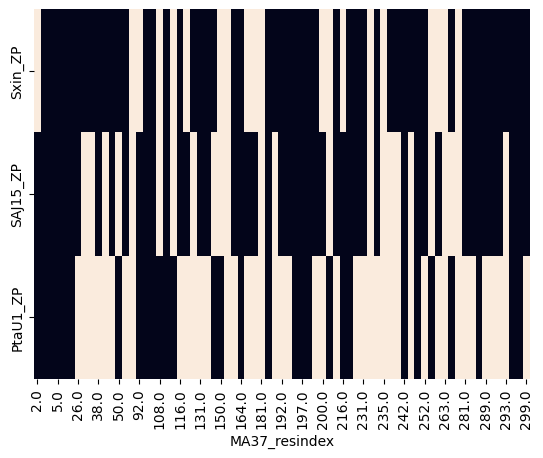

In [96]:

FlA_MSA_ZP_hm = FlA_MSA_ZP[FlA_MSA_ZP["Mut"] != "-"]
FlA_MSA_ZP_hm = FlA_MSA_ZP_hm.set_index("MA37_resindex")
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.drop(columns=["MA37", "Mut"]).drop(columns=variants)
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.transpose()
    
    
# print(FlA_MSA_ZP_hm)

sns.heatmap(FlA_MSA_ZP_hm, cbar=False)



In [98]:
MA37=list("""----------MAANGSQRPIIAFMSDLGTTDDSVAQCKGLMHSICPGVTVVDVCHSMTPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTTTRSVAVRIRQAAKGGARGQWAGSGDG
FERA-DGSYIYIAPNNGLLTTVLEEHGYIEAYEVTSTKVIPANPEPTFYSREMVAIPSAH
L-----AAGFPLAEVGRRLDDSEIVRFHRPAVEI-SGEALSGVVTAIDHPFGNIWTNIHR
TDLE-KAGIGQGKHLKIILDDVLPFEAPLTPTFADAGAIGNIAFYLNSRGYLSLARNAAS
LAYPYNLKAGLKVRVEAR---------------------""")
MA37 = [v for v in MA37 if v not in ["\n"]]

resn = len(MA37)
resi = np.zeros(resn)

# print(MA37)
n=0
for i in range(resn):
    
    if MA37[i] != "-":
        n+=1
        resi[i] = n

d = {"MA37_resindex" : resi, "MA37" : MA37}
FlA_MSA = pd.DataFrame(data=d)

Stro = list("""---------------MQHNLIAFLSDVGSADEAHALCKGVMYGVAPAATIVDITHDVAPF
DVREGALFLADVPHSFPAH-TVICATVYPETGTATHTIAVRN------------------
-----EKGQLLVGPNNGLLSFALDASPAVECHEVLSPDVMNQPVTPTWYSKDIVAACAAH
L-----AAGTDLAAVGPRIDPKQIVRLPYASASE-VEGGIRGEVVRIDRAFGNVWTNIPT
HLIGSMLQDGERLEVKIEALSDTVLELPFCKTFGEVD-EGQPLLYLNSRGRLALGLNQSN
FIEKWPVVPGDSITVSPRVPD---------SNLGPVLG-""")
Stro = [v for v in Stro if v not in ["\n"]]
FlA_MSA["Stro"] = Stro

PtaU1 = list("""MLQNTKNEYKPRDGGGHRPIIGFMSDLGTEDDSVGICKGVMLGLCPDAVIVDISHSMTPW
DIDQGSRLIVDLPKFFPNW-TTFATTSYRETGTSARSVAIKL------------------
-----PSGHVYVAPNNGLLTRVIEDHGYVEAYEVTTVGAIPAEPEPTWFSRDMVAYPAAA
I-----AAGFPLENVGRPLNDSEIVRADLPRYTQAEDGIIQGIVTTIDRPFGNIWTNIPR
RIIENELRIAYGTNIRVVLDNLLVLEVPFMRTFGDVG-LKKPMCYINSRGYFSLAYYGGN
LADPYNIRRGMPVKIESITR-------------------""")
PtaU1 = [v for v in PtaU1 if v not in ["\n"]]
FlA_MSA["PtaU1"] = PtaU1

Tnor = list("""--------------MDIGPIIGFASDLGLKDDSVALCKGLMISICPEVYIVDICHTMTPF
DIEEGAWLALDLPRFFPEGRTIFAVTTYPATGTEARSIAVRIKKAVPGGSLEKWEGPGGG
MERTLEGGYIYVAPNNGLLTFVLERYGYIEAYEIISTEFIPENPEPTFFSREMVAIRAAC
IAKKVVSQGVPLSKVGPPITEDKLARIKLSLPEKIAHNEIRGKIIRIDYPYGNVWTNISF
NDLK-SMGINYGSRLTVVIGDILSFNVYLTRTFADAGGIGDVISYINSRGYFSLGGYAAN
LADLCNLRRGMNVVVIKV---------------------""")
Tnor = [v for v in Tnor if v not in ["\n"]]
FlA_MSA["Tnor"] = Tnor

Pbac=list("""------MEKVDNKTVFQRPIIAFMSDLGAFDDSVGICKGLMLSVCPEAQIIDICHSMTPF
DVEQGARLIVDLPRFFPEGRTVFATTTYPATGTMARSLALRIKRPAKGGALGQWAGAGFG
IERG-VGGYIYVAPNNGLLTDVIEEHGYLEAYEITSTNVIPENPEPTFFSREMVALPSAY
L-----AAGYPLSEVGQPLGDSEIVRFKKVLPRKMSESELVGVVAAIDRPFGNVWTNISR
RDLD-KIGVTYGSQLKVVLDNALMFELPLSQTFADAREIGAAVAYINSRGHLSLGRYAAN
LADRYNINRGMPIRLKVITG-------------------""")
Pbac = [v for v in Pbac if v not in ["\n"]]
FlA_MSA["Pbac"] = Pbac

Cbac=list("""-----MQEGQATSTPRQRPVIAFMSDLGTFDDSVGICKGLMLSVCPDVVIVDICHAMTPF
DIEEGARLIVDLPRFFPEG-TVFATTTYPATGTSTRSVALRIRQAAVGGARGQWAGAGEG
IQRA-EGAYIYIAPNNGLLTSVIEEHGYLEAYEVTSTSVIPARPEPTFFSREMVAVPAAH
L-----AAGFPLSQVGRPLQDSEIVRFDRRRPASLGDGGFAGVITVVDRPYGNVWTNISR
KDLA-NQGIAYGTRLRITVDNVLPFDLTLTPTFADAGEIGAPVCYVNSRGYLSLARNASN
LADTYNIRRHMPVNVQVVSRTDGEPHRSESSELASVKGT""")
Cbac = [v for v in Cbac if v not in ["\n"]]
FlA_MSA["Cbac"] = Cbac

SAJ15=list("""----------MTSNGAHRPIIAFMSDLGTTDDSVAQCKGLMLSICPDVTIVDVCHSMTPF
DVEEGSRYIVDLPRFFPEG-TVFATTTYPATGTETRSVAVRIRQAAQGGARGQWAGSGAG
FERQ-EGSYIYIAPNNGLLTPVLEEHGYIEAYEVSSTEVIPERPEPTFYSREMVAIPSAH
L-----AAGFPLDQVGRPLKDSEIVRFSRPAVET-AGTELTGVVSAIDHPFGNIWTNIHR
TDLE-KAGIGYGRQIRITLDDVLPFELTLVPTFADAGEVGNVVAYLNSRGYLSLARNAAS
LAYPYNLKAGLSVRVDAH---------------------""")
SAJ15 = [v for v in SAJ15 if v not in ["\n"]]
FlA_MSA["SAJ15"] = SAJ15

Sxin=list("""----------MSADPTQRPIIGFMSDLGTTDDSVAQCKGLMHSICPGVTVIDVCHSMTPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTETRSVAVRIKQAAKGGARGQWAGSAGG
FERA-EGSYIYVAPNNGLLTTVLEEHGYIEAYEVSSTKVIPERPEPTFYSREMVAIPAAH
L-----AAGFPLSEVGRPLEDSEIVRYQPPQVEI-SGDTLTGVVSAIDHPFGNVWTNIHR
THLE-KAGIGYGKRIKIILDDVLPFEQTLVPTFADAGEIGGVAAYLNSRGYLSLARNAAS
LAYPFNLKAGLKVRVETN---------------------""")
Sxin = [v for v in Sxin if v not in ["\n"]]
FlA_MSA["Sxin"] = Sxin

Scat=list("""----------MAANSTRRPIIAFMSDLGTTDDSVAQCKGLMYSICPDVTVVDVCHSMTPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTTTRSVAVRIKQAAKGGARGQWAGSGAG
FERA-EGSYIYIAPNNGLLTTVLEEHGYLEAYEVTSPKVIPEQPEPTFYSREMVAIPSAH
L-----AAGFPLSEVGRPLEDHEIVRFNRPAVEQ-DGEALVGVVSAIDHPFGNVWTNIHR
TDLE-KAGIGYGARLRLTLDGVLPFEAPLTPTFADAGEIGNIAIYLNSRGYLSIARNAAS
LAYPYHLKEGMSARVEAR---------------------""")
Scat = [v for v in Scat if v not in ["\n"]]
FlA_MSA["Scat"] = Scat

Amza=list("""-----------MSDSYSRPIIAFMSDLGTTDDSVAQCKGLMMSICQDVTVVDVCHSMEPW
NVEEGARYIVDLPRFFPEG-TVFATTTYPATGTTARSVAVRIKYPAKGGARGQWAGSGEG
FERS-EGSYIYIAPNNGLLTTVLQEHGYTEAYEVSSTDVVPARPEPTFYSREMVAIPSAH
L-----AAGYPLEKVGRKLQDSEIVRFTPPQATVSPEGDLSGVVTAIDHPFGNIWTSIHR
DNLE-SAGVGYGTNLKIVLDDVFPFELPLSPTFADAGEVGDPVVYVNSRGYLSLARNAAS
LAYPYNLKEGMSVRVTRS---------------------""")
Amza = [v for v in Amza if v not in ["\n"]]
FlA_MSA["Amza"] = Amza

N902=list("""------------MPANGNPIIAFMSDLGTTDDSVAQCKGLMLSICPGVTIVDVNHSMTPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTATRSVALRIKQAAQGGARGQWAGSGAG
FERA-EGSYIYIAPNNGLLTTVIEEHGYIEAYEVSNTKVIPAEPEPTFYSREMVAIPSAH
L-----AAGFPLNEVGRALSDDEIVRFAKPKPSTVSGGVLSGVITNIDHPFGNLWTNIHR
TDLE-KAGIGYQTQLRLLLDGVLTFDLPLVPTFADAGQIGDPVIYINSRGYLALARNAAP
LAYPYNLKAGLTVTVTKA---------------------""")
N902 = [v for v in N902 if v not in ["\n"]]
FlA_MSA["N902"] = N902

Nbra2=list("""----------MTTANGRRPIIAFMSDLGITDDSVAQCKGLMLSVCPDVTIVDICHTMQPW
DVEEGARYIVDLPRLFPEG-TVFATTTYPATGTTARSVALRIAHASKGGARGQWAGSGAG
FERK-EGSYIYIAPNNGLLTTVIKEHGYLEAYEVSSPEVIPEQPEPTFYSREMVALPSAH
L-----AAGFPLEKVGRRLADDEIVRFERKDPELVADNELLGYVTNIDHPFGNVWTNIHR
TDLE-KLGVGYGTELRITLDGVLPFELPLSPTFADAGEVGAAVAYLSSRGYLALARNAAS
LAYPYNLNAGISVQVKVD---------------------""")
Nbra2 = [v for v in Nbra2 if v not in ["\n"]]
FlA_MSA["Nbra2"] = Nbra2

Nbra3=list("""----------MTTANGRRPIIAFMSDLGITDDSVAQCKGLMLSVCPDVTIVDICHTMQPW
DVEEGARYIVDLPRLFPEG-TVFATTTYPATGTTARSVALRIAHASKGGARGQWAGSGAG
FERK-EGSYIYIAPNNGLLTTVIKEHGYLEAYEVSSPEVIPEQPEPTFYSREMVALPSAH
L-----AAGFPLEKVGRRLADDEIVRFERKDPELVADTDLVGYVTNIDHPFGNVWTNIHR
TDLE-KLGVGYGTKLRITLDGVLPFELPLSPTFADAGEVGAAVAYLSSRGYLALARNAAS
LAYPYNLKAGISVQVKVG---------------------""")
Nbra3 = [v for v in Nbra3 if v not in ["\n"]]
FlA_MSA["Nbra3"] = Nbra3

Nbra1=list("""----------MTTTNGRRPIIAFMSDLGITDDSVAQCKGLMLSVCPDVTIVDICHTMQPW
DVEEGARYIVDLPRLFPEG-TVFATTTYPATGTTARSVALRIAHASKGGARGQWAGSGAG
FERK-EGSYIYIAPNNGLLTTVIKEHGYLEAYEVSSPEVIPEQPEPTFYSREMVALPSAH
L-----AAGFPLEKVGRRLADDEIVRFERKDPELVADHDLVGYVTNIDHPFGNVWTNIHR
TDLE-KLGVGYGTKLRITLDGVLPFELPLSPTFADAGEIGAAVAYLSSRGYLALARNAAS
LAYPYNLKAGISVQVKVG---------------------""")
Nbra1 = [v for v in Nbra1 if v not in ["\n"]]
FlA_MSA["Nbra1"] = Nbra1

AN11=list("""----------MASSRGNRPIIAFMSDLGITDDSVAQCKGLMLSVCPDVTIVDVCHTMKPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTTARSVAIRIKQAAKGGARGQWAGSGAG
FERA-EGSYIYIAPNNGLLTSVIEEHGYLEAYEVSSTEVIPELPEPTFYSREMVALPSGH
L-----AAGFPLNKVGRPLADDEIVRFTRPQPSVETDGDLVGVVTNIDHPFGNIWTNIHR
TDLE-RAGVGYGTKLKVVLDEVLPFELPLSPTFADAGPVGTPVAYLSSRGYLALARNAAS
LAYPYNLEAGIPVRVKVG---------------------""")
AN11 = [v for v in AN11 if v not in ["\n"]]
FlA_MSA["AN11"] = AN11

Abar=list("""------------MATTKRPVLAFMSDLGITDDSVAQCKGLMLSICPDVTIVDVCHTMTPW
DVEEGARYIVDLPRFFPEG-TVFATTTYPATGTGTRSVALRIKQAAKGGARGQWAGSGAG
FERA-EGSYIYIAPNNGLLTSVIEEHGYLEAYEVSSTEVIPEQPEPTFYSREMVAVPSAH
L-----AAGFPLEKVGRKLADDEIVRFDRPKPVQDEDGDLVGVVTTIDHPFGNVWTNIHR
EDLE-KAGVGYGTELTITLDEVLPFRLPLSPTFADAGPIGSPVAYLSSRGYLALARNAAS
LAYPYNIQAGIPVRVHVA---------------------""")
Abar = [v for v in Abar if v not in ["\n"]]
FlA_MSA["Abar"] = Abar

CA12=list("""------------MAKPSRPIIAFMSDLGITDDSVAQCKGLMLSVCPDVTIVDVCHTMKPW
DVEEGARYIVDLPRLFPEG-TVFATTTYPATGTTTRSVALRIKQAAKGGARGQWAGSGAG
FERA-EGSYIYIAPNNGLLTSVIEEHGYVEAYEVSSTEVIPEQPEPTFYSREMVALPSAH
L-----AAGFPLEKVGRPLADDEIVRFERAKPAQNDDGELVGVVTAIDHPFGNVWTNIHR
EDLE-KLGAGYGTRLRITLDEVLPFDLPLSPTFADAGPIGTPVAYLSSRGYLALARNAAS
LAYPYNLNAGISVRVVAA---------------------""")
CA12 = [v for v in CA12 if v not in ["\n"]]
FlA_MSA["CA12"] = CA12

# FlA_MSA.head(60)


Stro: 30
PtaU1: 44
Tnor: 43
Pbac: 49
Cbac: 48
SAJ15: 24
Sxin: 20
Scat: 21
Amza: 25
N902: 25
Nbra2: 32
Nbra3: 32
Nbra1: 32
AN11: 31
Abar: 35
CA12: 34


<Axes: xlabel='MA37_resindex'>

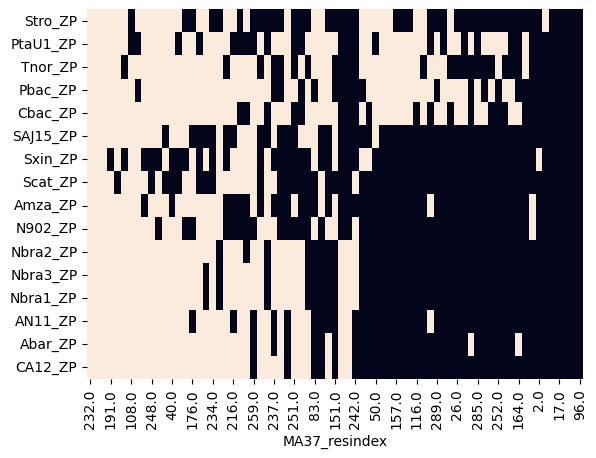

In [99]:
tranceptEVE = ZP_pred.loc[ZP_pred["TranceptEVE_bin"]==1].sort_values(by="TranceptEVE_score", ascending=False)

tranceptEVE["Pos"] = tranceptEVE["Pos"].str.replace(r"[\[\]]", "", regex=True).astype(int)
tranceptEVE["Mut"] = tranceptEVE["Mut"].str.replace(r"[\[\]\']", "", regex=True)

ZP_tranceptEVE = tranceptEVE.groupby("Pos").agg({"Mut": "".join}).reset_index()

# print(ZP_tranceptEVE)

variants = list(FlA_MSA.columns.values)
variants.remove("MA37_resindex")
variants.remove("MA37")

FlA_MSA_ZP = FlA_MSA.merge(ZP_tranceptEVE[["Pos", "Mut"]], 
                           left_on="MA37_resindex", right_on="Pos",
                           how="left")

FlA_MSA_ZP=FlA_MSA_ZP.drop(columns=["Pos"]).fillna("-")

for var in variants:
    FlA_MSA_ZP[f"{var}_ZP"] = 0
    for i in range (len(FlA_MSA_ZP)):
        if FlA_MSA_ZP.loc[i, var] in FlA_MSA_ZP.loc[i, "Mut"] and FlA_MSA_ZP.loc[i, var] != '-':
            FlA_MSA_ZP.loc[i,f"{var}_ZP"] = 1
            
    print(f"{var}: {FlA_MSA_ZP[f"{var}_ZP"].sum()}")
    
    
FlA_MSA_ZP_PtaU1 = FlA_MSA_ZP.loc[FlA_MSA_ZP["PtaU1_ZP"]==1]
# print(FlA_MSA_ZP_PtaU1)

FlA_MSA_ZP_hm = FlA_MSA_ZP[FlA_MSA_ZP["Mut"] != "-"]
FlA_MSA_ZP_hm = FlA_MSA_ZP_hm.set_index("MA37_resindex")
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.drop(columns=["MA37", "Mut"]).drop(columns=variants)
FlA_MSA_ZP_hm = FlA_MSA_ZP_hm.assign(count=FlA_MSA_ZP_hm.sum(axis=1)).sort_values(by="count", ascending=False).drop(columns=["count"])
FlA_MSA_ZP_hm.head(50)
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.transpose()



sns.heatmap(FlA_MSA_ZP_hm, cbar=False)


Stro: 9
PtaU1: 16
Tnor: 15
Pbac: 17
Cbac: 21
SAJ15: 12
Sxin: 10
Scat: 12
Amza: 12
N902: 10
Nbra2: 18
Nbra3: 17
Nbra1: 17
AN11: 15
Abar: 19
CA12: 17


<Axes: xlabel='MA37_resindex'>

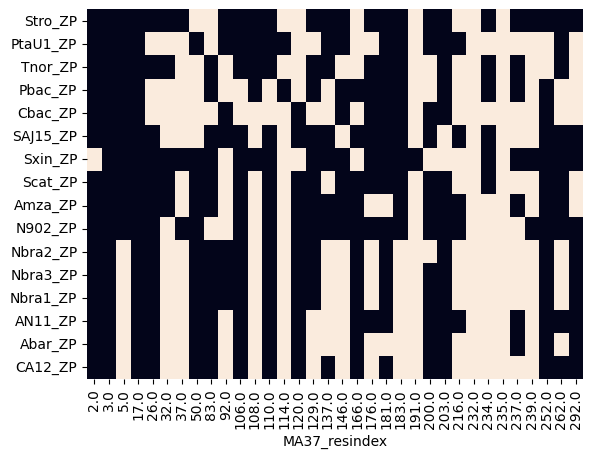

In [71]:
tranceptEVE = ZP_pred.loc[ZP_pred["TranceptEVE_bin"]==1]
tranceptEVExESMIF1 = tranceptEVE.loc[ZP_pred["ESM-IF1_bin"]==1].sort_values(by="IF1-TranceptEVE", ascending=False)

tranceptEVExESMIF1["Pos"] = tranceptEVExESMIF1["Pos"].str.replace(r"[\[\]]", "", regex=True).astype(int)
tranceptEVExESMIF1["Mut"] = tranceptEVExESMIF1["Mut"].str.replace(r"[\[\]\']", "", regex=True)

ZP_tranceptEVExESMIF1 = tranceptEVExESMIF1.groupby("Pos").agg({"Mut": "".join}).reset_index()

variants = list(FlA_MSA.columns.values)
variants.remove("MA37_resindex")
variants.remove("MA37")

FlA_MSA_ZP = FlA_MSA.merge(ZP_tranceptEVExESMIF1[["Pos", "Mut"]], 
                           left_on="MA37_resindex", right_on="Pos",
                           how="left")

FlA_MSA_ZP=FlA_MSA_ZP.drop(columns=["Pos"]).fillna("-")

for var in variants:
    FlA_MSA_ZP[f"{var}_ZP"] = 0
    for i in range (len(FlA_MSA_ZP)):
        if FlA_MSA_ZP.loc[i, var] in FlA_MSA_ZP.loc[i, "Mut"] and FlA_MSA_ZP.loc[i, var] != '-':
            FlA_MSA_ZP.loc[i,f"{var}_ZP"] = 1
            
    print(f"{var}: {FlA_MSA_ZP[f"{var}_ZP"].sum()}")

FlA_MSA_ZP_hm = FlA_MSA_ZP[FlA_MSA_ZP["Mut"] != "-"]
FlA_MSA_ZP_hm = FlA_MSA_ZP_hm.set_index("MA37_resindex")
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.drop(columns=["MA37", "Mut"]).drop(columns=variants)
FlA_MSA_ZP_hm=FlA_MSA_ZP_hm.transpose()

sns.heatmap(FlA_MSA_ZP_hm, cbar=False)